In [1]:
import pandas as pd

df = pd.read_csv("hour.csv")

print("Shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())
print("\nData types:")
print(df.dtypes)
print("\nFirst 5 rows:")
df.head()

Shape: (17379, 17)

Column names:
['instant', 'dteday', 'season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'casual', 'registered', 'cnt']

Data types:
instant         int64
dteday            str
season          int64
yr              int64
mnth            int64
hr              int64
holiday         int64
weekday         int64
workingday      int64
weathersit      int64
temp          float64
atemp         float64
hum           float64
windspeed     float64
casual          int64
registered      int64
cnt             int64
dtype: object

First 5 rows:


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


In [2]:
print("Missing values:")
print(df.isnull().sum())

print("\nBasic statistics:")
print(df[['temp', 'hum', 'windspeed', 'cnt']].describe())

print("\nData coverage:")
print(f"Years: {df['yr'].unique()} (0=2011, 1=2012)")
print(f"Unique days: {df['dteday'].nunique()}")
print(f"Total hours: {len(df)}")
print(f"Avg rentals per hour: {df['cnt'].mean():.1f}")
print(f"Busiest hour ever: {df['cnt'].max()} rentals")
print(f"Quietest hour ever: {df['cnt'].min()} rentals")

Missing values:
instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

Basic statistics:
               temp           hum     windspeed           cnt
count  17379.000000  17379.000000  17379.000000  17379.000000
mean       0.496987      0.627229      0.190098    189.463088
std        0.192556      0.192930      0.122340    181.387599
min        0.020000      0.000000      0.000000      1.000000
25%        0.340000      0.480000      0.104500     40.000000
50%        0.500000      0.630000      0.194000    142.000000
75%        0.660000      0.780000      0.253700    281.000000
max        1.000000      1.000000      0.850700    977.000000

Data coverage:
Years: [0 1] (0=2011, 1=2012)
Unique days: 731
Total hours: 17379
Avg rentals per hour: 189.5
Busiest hour

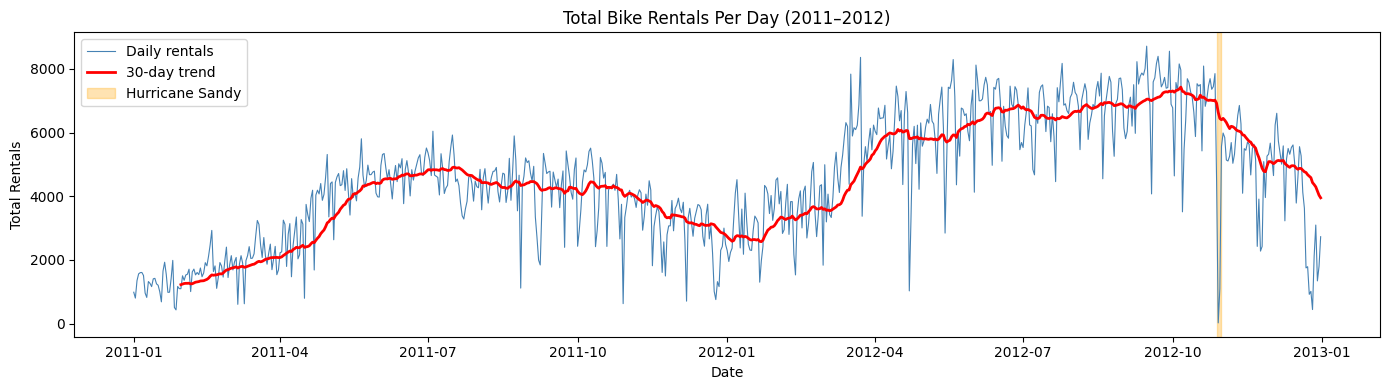

In [3]:
import matplotlib.pyplot as plt
import numpy as np

df['dteday'] = pd.to_datetime(df['dteday'])
daily = df.groupby('dteday')['cnt'].sum()

plt.figure(figsize=(14, 4))
plt.plot(daily.index, daily.values, color='steelblue', linewidth=0.8, label='Daily rentals')

# Add a 30-day rolling average trend line
rolling = daily.rolling(30).mean()
plt.plot(daily.index, rolling.values, color='red', linewidth=2, label='30-day trend')

# Highlight Hurricane Sandy
plt.axvspan('2012-10-28', '2012-10-31', color='orange', alpha=0.3, label='Hurricane Sandy')

plt.title('Total Bike Rentals Per Day (2011–2012)')
plt.xlabel('Date')
plt.ylabel('Total Rentals')
plt.legend()
plt.tight_layout()
plt.show()

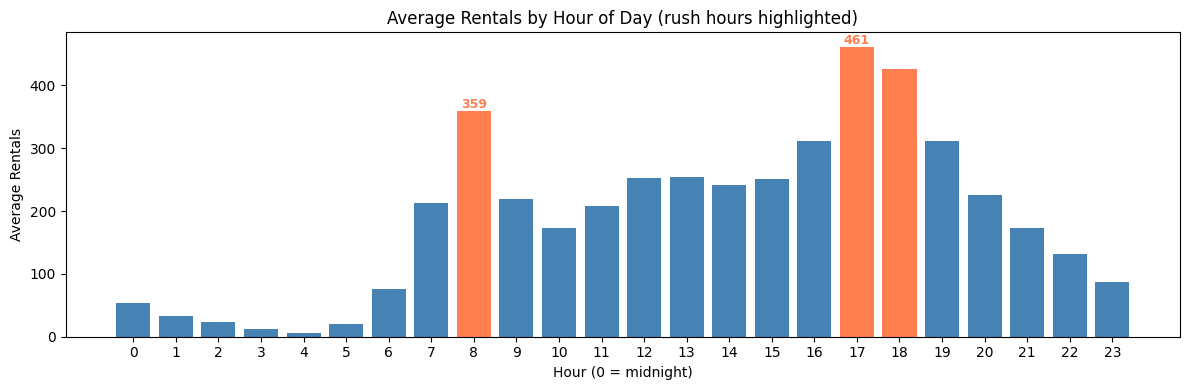

In [4]:
import seaborn as sns

hourly = df.groupby('hr')['cnt'].mean()

# Color rush hours differently
colors = ['coral' if h in [8, 17, 18] else 'steelblue' for h in hourly.index]

plt.figure(figsize=(12, 4))
bars = plt.bar(hourly.index, hourly.values, color=colors)

# Add value labels on the two biggest bars
for h in [8, 17]:
    plt.text(h, hourly[h] + 5, f'{hourly[h]:.0f}', 
             ha='center', fontsize=9, fontweight='bold', color='coral')

plt.title('Average Rentals by Hour of Day (rush hours highlighted)')
plt.xlabel('Hour (0 = midnight)')
plt.ylabel('Average Rentals')
plt.xticks(range(24))
plt.tight_layout()
plt.show()

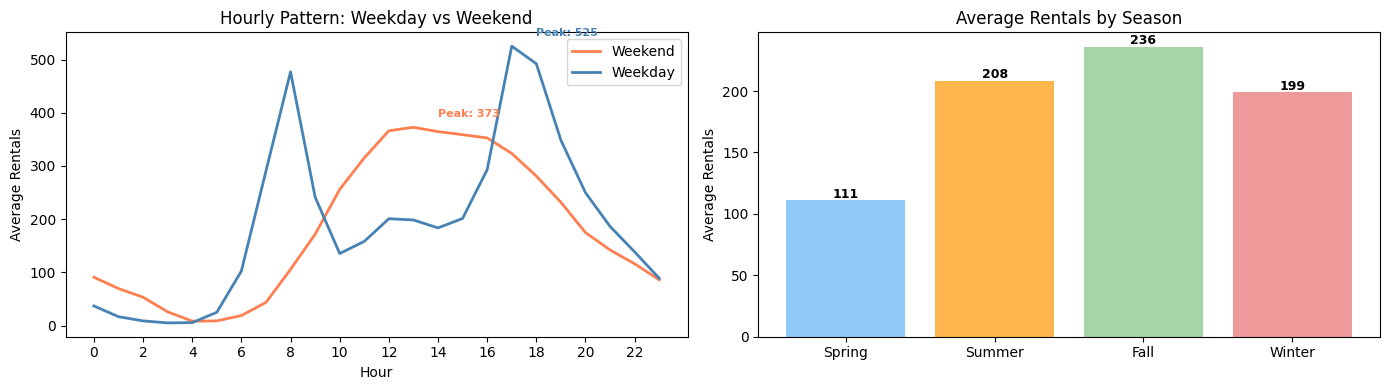

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left — Weekday vs Weekend
for day_type, label, color in [(0, 'Weekend', 'coral'), (1, 'Weekday', 'steelblue')]:
    subset = df[df['workingday'] == day_type]
    hourly = subset.groupby('hr')['cnt'].mean()
    axes[0].plot(hourly.index, hourly.values, label=label, color=color, linewidth=2)
    # Mark the peak hour
    peak_hr = hourly.idxmax()
    axes[0].annotate(f'Peak: {hourly[peak_hr]:.0f}',
                     xy=(peak_hr, hourly[peak_hr]),
                     xytext=(peak_hr + 1, hourly[peak_hr] + 20),
                     fontsize=8, color=color, fontweight='bold')

axes[0].set_title('Hourly Pattern: Weekday vs Weekend')
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('Average Rentals')
axes[0].legend()
axes[0].set_xticks(range(0, 24, 2))

# Right — Season
seasonal = df.groupby('season')['cnt'].mean()
season_colors = ['#90CAF9', '#FFB74D', '#A5D6A7', '#EF9A9A']
bars = axes[1].bar(['Spring','Summer','Fall','Winter'], 
                    seasonal.values, color=season_colors)

# Add value on top of each bar
for bar, val in zip(bars, seasonal.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                f'{val:.0f}', ha='center', fontsize=9, fontweight='bold')

axes[1].set_title('Average Rentals by Season')
axes[1].set_ylabel('Average Rentals')

plt.tight_layout()
plt.show()

In [6]:
# Convert date
df['dteday'] = pd.to_datetime(df['dteday'])

# Time-based features
df['hour'] = df['hr']
df['month'] = df['dteday'].dt.month
df['day_of_week'] = df['dteday'].dt.dayofweek
df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)
df['is_rush_hour'] = df['hour'].isin([7, 8, 9, 17, 18, 19]).astype(int)
df['quarter'] = df['dteday'].dt.quarter

# Temperature category (temp is normalized 0-1, so 0.5 ≈ 20°C)
df['temp_category'] = pd.cut(df['temp'], 
                              bins=[0, 0.25, 0.5, 0.75, 1.0],
                              labels=[0, 1, 2, 3]).astype(int)

# Lag features
df = df.sort_values('dteday').reset_index(drop=True)
df['lag_1hr'] = df['cnt'].shift(1)
df['lag_24hr'] = df['cnt'].shift(24)
df['lag_168hr'] = df['cnt'].shift(168)

# Rolling averages
df['rolling_3hr'] = df['cnt'].shift(1).rolling(3).mean()
df['rolling_24hr'] = df['cnt'].shift(1).rolling(24).mean()

# Drop NaN rows
df = df.dropna().reset_index(drop=True)

print("New shape:", df.shape)
print("Features created successfully!")
df[['dteday', 'hour', 'is_weekend', 'is_rush_hour', 
    'temp_category', 'lag_1hr', 'rolling_24hr', 'cnt']].head(5)

New shape: (17211, 29)
Features created successfully!


,dteday,hour,is_weekend,is_rush_hour,temp_category,lag_1hr,rolling_24hr,cnt
0,2011-01-08,17,1,1,0,55.0,51.708333,69
1,2011-01-08,16,1,0,0,69.0,52.958333,76
2,2011-01-08,15,1,0,0,76.0,54.625000,74
3,2011-01-08,13,1,0,0,74.0,57.083333,102
4,2011-01-08,12,1,0,0,102.0,57.375000,98


In [7]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

features = ['hour', 'month', 'day_of_week', 'is_weekend', 'is_rush_hour',
            'quarter', 'workingday', 'holiday', 'season', 'weathersit',
            'temp', 'hum', 'windspeed', 'temp_category',
            'lag_1hr', 'lag_24hr', 'lag_168hr', 'rolling_3hr', 'rolling_24hr']

X = df[features]
y = df['cnt']

# Time-aware split
split = int(len(df) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# Show what dates are being trained/tested on
print(f"Training period: {df['dteday'].iloc[0].date()} → {df['dteday'].iloc[split].date()}")
print(f"Testing period:  {df['dteday'].iloc[split].date()} → {df['dteday'].iloc[-1].date()}")
print(f"\nTraining on {len(X_train):,} hours")
print(f"Testing on  {len(X_test):,} hours")

# Train
print("\nTraining model...")
model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)
print("Model trained successfully! ✓")

Training period: 2011-01-08 → 2012-08-08
Testing period:  2012-08-08 → 2012-12-31

Training on 13,768 hours
Testing on  3,443 hours

Training model...
Model trained successfully! ✓


Metric        Our Model     Baseline
MAE                42.1        146.5
RMSE               65.9        209.7
Improvement        71.3%            —


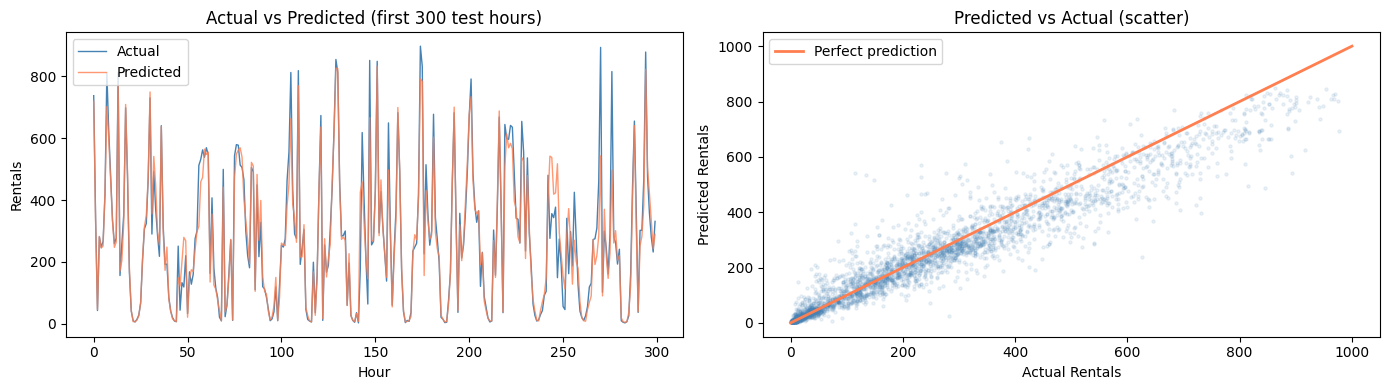

In [8]:
y_pred = model.predict(X_test)
baseline_pred = X_test['lag_1hr']

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
baseline_mae = mean_absolute_error(y_test, baseline_pred)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))

print("=" * 45)
print(f"{'Metric':<10} {'Our Model':>12} {'Baseline':>12}")
print("=" * 45)
print(f"{'MAE':<10} {mae:>12.1f} {baseline_mae:>12.1f}")
print(f"{'RMSE':<10} {rmse:>12.1f} {baseline_rmse:>12.1f}")
print(f"{'Improvement':<10} {((baseline_mae-mae)/baseline_mae*100):>11.1f}% {'—':>12}")
print("=" * 45)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left — time series prediction
axes[0].plot(y_test.values[:300], label='Actual', color='steelblue', linewidth=1)
axes[0].plot(y_pred[:300], label='Predicted', color='coral', linewidth=1, alpha=0.8)
axes[0].set_title('Actual vs Predicted (first 300 test hours)')
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('Rentals')
axes[0].legend()

# Right — scatter plot
axes[1].scatter(y_test, y_pred, alpha=0.1, color='steelblue', s=5)
axes[1].plot([0, 1000], [0, 1000], color='coral', linewidth=2, label='Perfect prediction')
axes[1].set_title('Predicted vs Actual (scatter)')
axes[1].set_xlabel('Actual Rentals')
axes[1].set_ylabel('Predicted Rentals')
axes[1].legend()

plt.tight_layout()
plt.show()

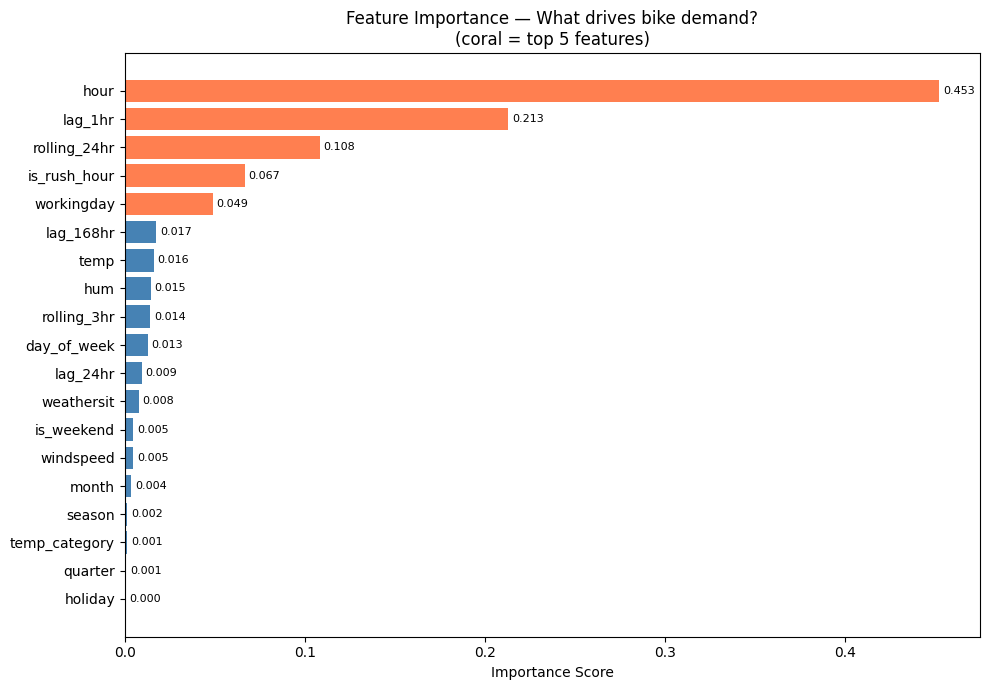

In [9]:
importance = pd.Series(model.feature_importances_, index=features)
importance = importance.sort_values(ascending=True)

# Color top 5 differently
colors = ['coral' if i >= len(importance) - 5 else 'steelblue' 
          for i in range(len(importance))]

plt.figure(figsize=(10, 7))
bars = plt.barh(importance.index, importance.values, color=colors)

# Add score labels
for bar, val in zip(bars, importance.values):
    plt.text(val + 0.002, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=8)

plt.title('Feature Importance — What drives bike demand?\n(coral = top 5 features)')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()